<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/src/lunar_SARSAsemi.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# SARSA Semigradiente con tilings en el problema LunarLander-v3

*Description*: Implementación y análisis del algoritmo SARSA Semi-gradiente utilizando aproximación de funciones mediante tilings para resolver el problema LunarLander-v3.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22

## Preparación del entorno

In [1]:
import sys
if 'google.colab' in sys.modules:
    # Definimos que el entorno es Colab
    en_colab = True
    print("Ejecutando en Google Colab")
else:
    # Definimos que el entorno es local
    en_colab = False
    print("Ejecutando en entorno local")

if en_colab:
    #@title Copiar el repositorio.
    print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
    !git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
    !cd EML_Carrillo_Ibarrola_Palomar/

    #@title Importamos todas las clases y funciones
    # Añadir los directorio fuentes al path de Python
    sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src/')
    # Verificar que se han añadido correctamente
    print(sys.path)

    !pip install -r ./EML_Carrillo_Ibarrola_Palomar/requirements.txt

    dir_base = "./EML_Carrillo_Ibarrola_Palomar/entornos_complejos"
else:
    dir_base = ".."

Ejecutando en entorno local


In [2]:
from tqdm import tqdm
import random
import numpy as np
import gymnasium as gym
from agents import TileCodingEnv, LunarAgentSARSA

random.seed(42)
np.random.seed(42)

## Experimento

El experimento evalúa el rendimiento del algoritmo **Semi-Gradient SARSA con aproximación mediante redes neuronales** en el entorno **LunarLander-v3**, un problema clásico de **aprendizaje por refuerzo con espacio de estados continuo**.

Este entorno modela el problema de **optimización de trayectoria de un módulo lunar**, donde el agente debe aprender a controlar los motores para realizar un aterrizaje seguro en la plataforma situada en la coordenada $(0,0)$.

El entorno se caracteriza por:

* **Espacio de estados**. Vector continuo de 8 dimensiones (float32) que representa:
  * Posición del módulo en $x$ y $y$
  * Velocidad lineal en $x$ y $y$
  * Ángulo del módulo
  * Velocidad angular
  * Dos variables booleanas que indican si cada pata está en contacto con el suelo

* **Espacio de acciones**. Consta de 4 acciones discretas:
  * 0: no hacer nada
  * 1: activar motor lateral izquierdo
  * 2: activar motor principal
  * 3: activar motor lateral derecho

* **Recompensa.** En cada paso se otorga una recompensa basada en varios factores:
  * Aumenta cuanto más cerca está el módulo de la plataforma
  * Aumenta cuanto menor es la velocidad
  * Disminuye cuanto más inclinado está el módulo
  * $+10$ puntos por cada pata en contacto con el suelo
  * $-0.03$ por motor lateral
  * $-0.3$ por motor principal
  * $+100$ si el aterrizaje es seguro
  * $-100$ si el módulo se estrella

* **Terminación del episodio**. Un episodio finaliza cuando:
  * el módulo se estrella contra la superficie lunar
  * el módulo sale del área visible
  * el sistema detecta que el módulo ha quedado en reposo tras aterrizar

Un episodio se considera resuelto si obtiene una recompensa total $\geq 200$.

In [3]:

def train_agent_SARSA(agent, n_episodes, saving=False):  
    env = agent.env

    for n in tqdm(range(n_episodes)):
        obs, info = env.reset()
        done = False

        # Play one complete episode
        action = agent.get_action(obs)                    
        
        while not done:
            next_obs, reward, terminated, truncated, info = env.step(action)        

            next_action = agent.get_action(next_obs)                  

            # Update Q-values (Semigradient SARSA)
            agent.update(obs = obs, action = action, reward = reward, terminated = terminated, next_obs = next_obs, next_action = next_action)    

            # Move to next state
            done = terminated or truncated
            obs = next_obs
            action = next_action

        # Reduce exploration rate (agent becomes less random over time)
        agent.decay_epsilon()

100%|██████████| 10000/10000 [02:46<00:00, 60.21it/s]


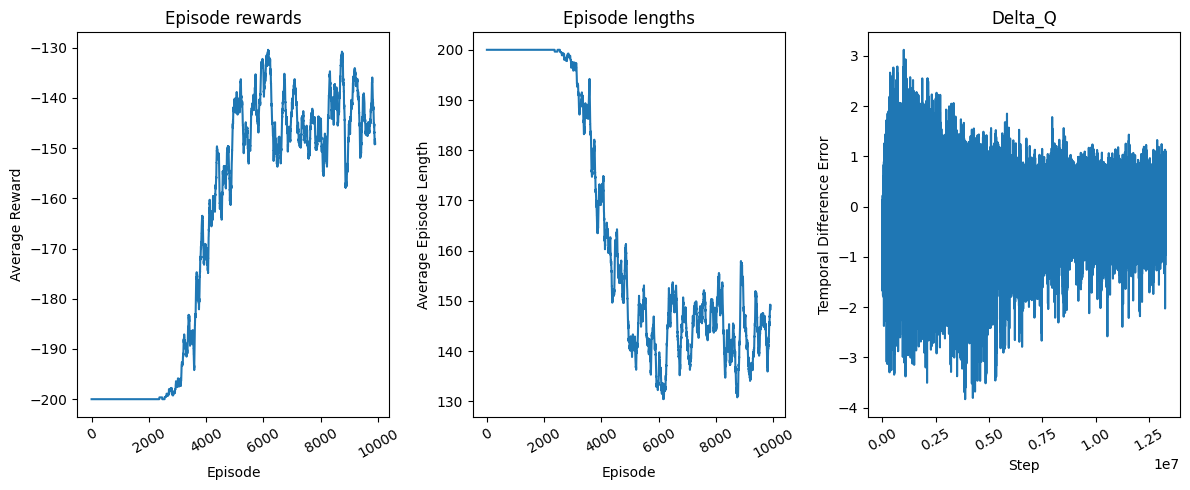

In [4]:

# ----- CONFIGURACIÓN Y EJECUCIÓN -----

learning_rate, n_episodes = (0.2, 10000) # LunarLander puede necesitar bastantes episodios

# # Creamos el entorno original y lo envolvemos en nuestro Tile Coder
base_env = gym.make("MountainCar-v0")  # Cambia a "LunarLander-v2" si quieres probar con ese entorno
# # 4 bins por cada una de las 8 dimensiones
bins = np.array([20, 20])  # número de intervalos por dimensión
n_tilings = 8
env = TileCodingEnv(base_env, low=base_env.observation_space.low, high=base_env.observation_space.high, bins=bins, n_tilings=n_tilings)

# # Utilizamos RecordEpisodeStatistics para el tracking (requiere acceder a env.unwrapped.return_queue)
# env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

initial_epsilon = 1.0
final_epsilon = 0.05
ratio = 0.5 # Exploramos durante el 50% del entrenamiento

# agent = LunarAgentSARSA(
#     env=env,
#     learning_rate=learning_rate,
#     initial_epsilon=initial_epsilon,
#     epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
#     final_epsilon=final_epsilon,
#     decay_type="linear"
# )
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)
env.bins = bins
env.n_tilings = n_tilings
# 4. Envolvemos para estadísticas
#env = gym.wrappers.RecordEpisodeStatistics(saenv, buffer_length=n_episodes)

# 5. Pasamos el entorno al agente
# El agente ahora podrá acceder a n_tilings si lo modificamos ligeramente 
# o si usamos las variables que ya extrajimos.
agent = LunarAgentSARSA(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=initial_epsilon,
    epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
    final_epsilon=final_epsilon,
    decay_type="linear"
)

saved_episodes = train_agent_SARSA(agent, n_episodes, saving=True)

import utils
utils.plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=100)


In [5]:
agent.test()

Test Results over 1000 episodes:
Win Rate: 0.0%
Average Reward: -128.911
Standard Deviation: 27.994


(np.float64(0.0), np.float64(-128.911), np.float64(27.99409007272785))

In [6]:

# # 2. Aplicamos TU Tile Coding
# # Suponiendo que bins y n_tilings están definidos

# tile_env = TileCodingEnv(base_env, bins=bins, low=base_env.observation_space.low, high=base_env.observation_space.high, n_tilings=4)


# # 4. Envolvemos para estadísticas
# env = gym.wrappers.RecordEpisodeStatistics(tile_env, buffer_length=n_episodes)

# # 5. Pasamos el entorno al agente
# # El agente ahora podrá acceder a n_tilings si lo modificamos ligeramente 
# # o si usamos las variables que ya extrajimos.
# agent = LunarAgentSARSA(
#     env=env,
#     learning_rate=learning_rate,
#     initial_epsilon=initial_epsilon,
#     epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
#     final_epsilon=final_epsilon,
#     decay_type="linear"
# )

# saved_episodes = train_agent_SARSA(agent, n_episodes, saving=True)

# # Evaluación rápida usando la cola de recompensas del wrapper
# import matplotlib.pyplot as plt
# returns = np.array(env.return_queue).flatten()
# plt.plot(returns)
# plt.title('Recompensas de LunarLander (Semigradiente SARSA)')
# plt.xlabel('Episodios')
# plt.ylabel('Recompensa Total')
# plt.show()

# print(f"Recompensa promedio de los últimos 100 episodios: {np.mean(returns[-100:])}")

# Nota: Tus funciones utils.plot_training_metrics y taxi_gif.animar_estados_taxi_gif
# deben ser reescritas para procesar imágenes continuas si quieres usarlas aquí.

In [7]:
import gymnasium as gym
import numpy as np

def visualize_solution(agent, env_name="MountainCar-v0", n_tilings=8, bins=None, seed=None):
    # Creamos el entorno base con render
    base_env = gym.make(env_name, render_mode="human")
    
    # Envolvemos con Tile Coding si bins fueron proporcionados
    if bins is not None:
        # Extraemos los límites del espacio de observación del entorno base
        low = base_env.observation_space.low
        high = base_env.observation_space.high
        
        # Pasamos low, high, y usamos 'n' en lugar de 'n_tilings'
        tile_env = TileCodingEnv(base_env, bins=bins, low=low, high=high, n_tilings = n_tilings)
    else:
        tile_env = base_env  # si no usamos Tile Coding

    # Recordamos estadísticas (opcional)
    env = gym.wrappers.RecordEpisodeStatistics(tile_env, buffer_length=1)
    
    obs, info = env.reset(seed=seed)
    done = False
    total_reward = 0
    step_count = 0
    
    while not done:
        # obs ya está en formato Tile Coding si usamos tile_env
        action = agent.get_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step_count += 1

    print(f"Total reward del episodio visualizado: {total_reward:.2f}")
    env.close()

# ----- USO -----
# Reutiliza los bins y n_tilings que usaste para entrenar
visualize_solution(agent, bins=bins, n_tilings = n_tilings)

Total reward del episodio visualizado: -145.00


In [8]:
import imageio
import base64
from IPython.display import HTML
def run_episode_greedy_lunarlander(agent, env, max_steps=1000):
    frames = []
    obs, _ = env.reset()
    agent.epsilon = 0.0  # Forzamos a ser completamente greedy
    
    for _ in range(max_steps):
        frame = env.render()
        frames.append(frame)

        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        obs = next_obs
        
        if terminated or truncated:
            frames.append(env.render())
            break

    return frames

def frames_to_gif(frames, filename=dir_base+"/data/results/SARSAsemi/mountaincar_sarsa.gif"):
    with imageio.get_writer(filename, mode='I') as writer:
        for frame in frames:
            writer.append_data(frame)
    return filename

def display_gif(gif_path):
    with open(gif_path, 'rb') as f:
        video = f.read()
    b64 = base64.b64encode(video)
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

GIF guardado en: ../data/results/SARSAsemi/mountaincar_sarsa.gif



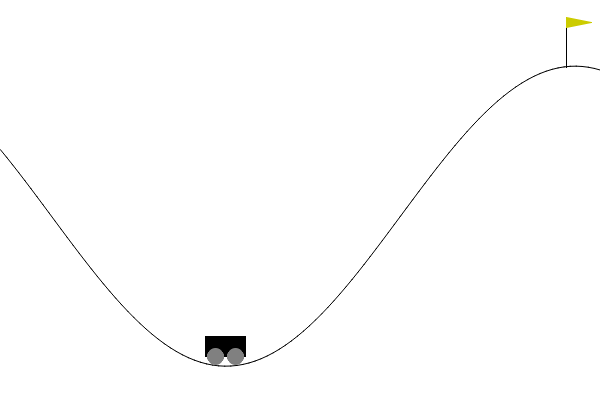

In [9]:
# Crear entorno con modo render para capturar imágenes
env_demo = gym.make("MountainCar-v0", render_mode='rgb_array')
env_demo = TileCodingEnv(env_demo, bins=bins, low=env_demo.observation_space.low, high=env_demo.observation_space.high, n_tilings=n_tilings)
state_dim = env_demo.observation_space.shape[0]
action_dim = env_demo.action_space.n

# Ejecutar episodio greedy
frames = run_episode_greedy_lunarlander(agent, env_demo, max_steps=1000)

env_demo.close()

# Crear GIF
gif_path = frames_to_gif(frames)
print("GIF guardado en:", gif_path)

# Mostrar GIF
display_gif(gif_path)